# Renewal Probability Prediction - Exploratory Data Analysis

## Purpose
This notebook performs comprehensive EDA to predict the likelihood that a customer will renew their contract based on:
- Account health and risk indicators
- Relationship and sentiment scores
- License utilization patterns
- Contract duration and renewal timeline
- Payment history and support interactions
- Churn probability from churn prediction model

## Key Metrics Analyzed
- **Renewal Probability** - Likelihood of contract renewal (0.0 to 1.0)
- **Renewal Stage** - Current stage (t90, t60, t30) - days until renewal
- **Account Health** - Health score and risk indicators
- **Relationship Strength** - Relationship and sentiment scores
- **Utilization** - License usage patterns
- **Contract Maturity** - Contract duration and renewal timeline
- **Churn Risk** - Churn probability from predictive model

In [14]:
# Install required packages
!uv add pandas numpy matplotlib seaborn openpyxl scikit-learn

Resolved 54 packages in 2ms
Audited 47 packages in 5ms


In [15]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import datetime, timedelta
import warnings

warnings.filterwarnings('ignore')

# Set style for better visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['font.size'] = 10

print("Libraries imported successfully!")

Libraries imported successfully!


## 1. Load and Explore Data

In [16]:
# Load the dataset
# Try multiple possible paths
possible_paths = [
    Path("../../customer_data_25000.xlsx"),
    Path("../customer_data_25000.xlsx"),
    Path("customer_data_25000.xlsx"),
    Path("D:/Internship/Renewal-Upsell-Advisor/Research/customer_data_25000.xlsx")
]

data_path = None
for path in possible_paths:
    if path.exists():
        data_path = path
        break

if data_path is None:
    raise FileNotFoundError("Could not find customer_data_25000.xlsx. Please check the file path.")

df = pd.read_excel(data_path, sheet_name="Accounts")

print(f"Dataset loaded successfully!")
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nColumn Names:")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:2d}. {col}")

print(f"\nFirst few rows:")
df.head()

Dataset loaded successfully!
Shape: 24,874 rows × 27 columns

Column Names:
   1. name
   2. domain
   3. industry
   4. company_size
   5. arr
   6. mrr
   7. contract_start_date
   8. contract_end_date
   9. renewal_date
  10. last_contact_date
  11. status
  12. renewal_stage
  13. health_score
  14. risk_score
  15. relationship_score
  16. churn_probability
  17. sentiment_score
  18. sentiment_category
  19. licenses_total
  20. licenses_used
  21. utilization_percentage
  22. csm_name
  23. csm_email
  24. primary_contact_name
  25. primary_contact_email
  26. primary_contact_phone
  27. salesforce_id

First few rows:


,name,domain,industry,company_size,arr,mrr,contract_start_date,contract_end_date,renewal_date,last_contact_date,...,sentiment_category,licenses_total,licenses_used,utilization_percentage,csm_name,csm_email,primary_contact_name,primary_contact_email,primary_contact_phone,salesforce_id
0,Cole LLC,colellc.com,Technology,Small,156049,13004.08,2025-06-05,2026-06-05,2026-06-05,2026-02-13 16:43:27,...,neutral,20,15,79,Sarah Chen,sarah.chen@company.com,Danielle Johnson,john21@example.net,001-581-896-0013x3890,NaN
1,"Stevens, Martinez and Nielsen",stevensmartinezandnielsen.com,Healthcare,Medium,517493,43124.42,2025-05-19,2026-05-19,2026-05-19,2026-02-04 16:43:27,...,positive,30,23,79,Maria Lopez,maria.lopez@company.com,Lisa Smith,helenpeterson@example.org,651.216.1559,NaN
2,Clark-Adams,clark-adams.com,Analytics,Large,64898,5408.17,2025-04-28,2026-04-28,2026-04-28,2026-02-12 16:43:27,...,negative,20,14,73,Emily Rodriguez,emily.rodriguez@company.com,Christian Carter,barbara10@example.net,441.731.6475,SF-748564
3,"Porter, Wilkerson and Day",porterwilkersonandday.com,Healthcare,Medium,43003,3583.58,2025-05-01,2026-05-01,2026-05-01,2026-02-06 16:43:27,...,neutral,20,14,73,David Kim,david.kim@company.com,Sharon Wong,amandasanchez@example.com,(748)535-0305x6413,SF-319684
4,Carlson-Mcdonald,carlson-mcdonald.com,Enterprise,Medium,100005,8333.75,2025-06-09,2026-06-09,2026-06-09,2026-01-19 16:43:27,...,very_positive,50,33,66,Sarah Chen,sarah.chen@company.com,Douglas Taylor,julie69@example.com,(332)887-1012x269,SF-944151


In [17]:
# Basic information about the dataset
print("=" * 80)
print("DATASET INFORMATION")
print("=" * 80)
print(f"\nTotal Records: {len(df):,}")
print(f"Total Columns: {len(df.columns)}")
print(f"\nData Types:")
print(df.dtypes)

print(f"\nMissing Values:")
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing Percentage': missing_pct
}).sort_values('Missing Count', ascending=False)
print(missing_df[missing_df['Missing Count'] > 0])

print(f"\nBasic Statistics for Key Renewal Features:")
renewal_features = ['health_score', 'risk_score', 'relationship_score', 'sentiment_score', 
                    'churn_probability', 'utilization_percentage', 'arr', 'mrr']
available_features = [f for f in renewal_features if f in df.columns]
if available_features:
    print(df[available_features].describe())

DATASET INFORMATION

Total Records: 24,874
Total Columns: 27

Data Types:
name                          str
domain                        str
industry                      str
company_size                  str
arr                         int64
mrr                       float64
contract_start_date           str
contract_end_date             str
renewal_date                  str
last_contact_date             str
status                        str
renewal_stage                 str
health_score                int64
risk_score                  int64
relationship_score          int64
churn_probability         float64
sentiment_score           float64
sentiment_category            str
licenses_total              int64
licenses_used               int64
utilization_percentage      int64
csm_name                      str
csm_email                     str
primary_contact_name          str
primary_contact_email         str
primary_contact_phone         str
salesforce_id                 str
dtype: o

## 2. Feature Engineering for Renewal Analysis

In [18]:
# Create a copy for renewal analysis
df_renewal = df.copy()

# Convert date columns to datetime
date_columns = ['contract_start_date', 'contract_end_date', 'renewal_date', 'last_contact_date']
for col in date_columns:
    if col in df_renewal.columns:
        df_renewal[col] = pd.to_datetime(df_renewal[col], errors='coerce')

# Calculate days until renewal
if 'renewal_date' in df_renewal.columns and 'days_until_renewal' not in df_renewal.columns:
    today = pd.Timestamp.now()
    df_renewal['days_until_renewal'] = (df_renewal['renewal_date'] - today).dt.days
    print(f"Calculated days_until_renewal")
    print(f"  Min: {df_renewal['days_until_renewal'].min():.0f} days")
    print(f"  Max: {df_renewal['days_until_renewal'].max():.0f} days")
    print(f"  Mean: {df_renewal['days_until_renewal'].mean():.2f} days")

# Calculate contract duration in months
if 'contract_start_date' in df_renewal.columns and 'contract_end_date' in df_renewal.columns:
    if 'contract_duration_months' not in df_renewal.columns:
        df_renewal['contract_duration_months'] = (
            (df_renewal['contract_end_date'] - df_renewal['contract_start_date']).dt.days / 30.44
        ).round(1)
        print(f"\nCalculated contract_duration_months")
        print(f"  Min: {df_renewal['contract_duration_months'].min():.1f} months")
        print(f"  Max: {df_renewal['contract_duration_months'].max():.1f} months")
        print(f"  Mean: {df_renewal['contract_duration_months'].mean():.2f} months")

# Create renewal stage categories based on days_until_renewal
if 'days_until_renewal' in df_renewal.columns:
    def categorize_renewal_stage(days):
        if pd.isna(days):
            return 'unknown'
        elif days < 0:
            return 'overdue'
        elif days <= 30:
            return 't30'
        elif days <= 60:
            return 't60'
        elif days <= 90:
            return 't90'
        else:
            return 't90+'
    
    if 'renewal_stage' not in df_renewal.columns or df_renewal['renewal_stage'].isna().any():
        df_renewal['renewal_stage_calculated'] = df_renewal['days_until_renewal'].apply(categorize_renewal_stage)
    else:
        df_renewal['renewal_stage_calculated'] = df_renewal['renewal_stage'].fillna('unknown')
    
    print(f"\nRenewal Stage Distribution:")
    print(df_renewal['renewal_stage_calculated'].value_counts())

# Calculate days since last contact
if 'last_contact_date' in df_renewal.columns:
    today = pd.Timestamp.now()
    df_renewal['days_since_last_contact'] = (today - df_renewal['last_contact_date']).dt.days
    print(f"\nDays Since Last Contact:")
    print(f"  Mean: {df_renewal['days_since_last_contact'].mean():.1f} days")
    print(f"  Median: {df_renewal['days_since_last_contact'].median():.1f} days")

# Create renewal target variable (if status column exists)
if 'status' in df_renewal.columns:
    print(f"\nStatus Distribution:")
    print(df_renewal['status'].value_counts())
    
    # Create binary renewal indicator
    # Assuming 'active', 'renewed', 'renewal' indicate renewal, others indicate non-renewal
    renewal_keywords = ['active', 'renewed', 'renewal', 'renew']
    df_renewal['will_renew'] = df_renewal['status'].str.lower().str.contains('|'.join(renewal_keywords), na=False).astype(int)
    print(f"\nRenewal Target Variable (will_renew):")
    print(df_renewal['will_renew'].value_counts())
    print(f"Renewal Rate: {df_renewal['will_renew'].mean():.2%}")

print(f"\n{'='*80}")
print("Feature Engineering Complete!")
print(f"{'='*80}")

Calculated days_until_renewal
  Min: 29 days
  Max: 119 days
  Mean: 74.09 days

Calculated contract_duration_months
  Min: 12.0 months
  Max: 12.0 months
  Mean: 12.00 months

Renewal Stage Distribution:
renewal_stage_calculated
t90        12412
t60         8136
renewed     4022
t30          304
Name: count, dtype: int64

Days Since Last Contact:
  Mean: 15.0 days
  Median: 15.0 days

Status Distribution:
status
active     16847
renewed     3239
at_risk     2449
churned     2339
Name: count, dtype: int64

Renewal Target Variable (will_renew):
will_renew
1    20086
0     4788
Name: count, dtype: int64
Renewal Rate: 80.75%

Feature Engineering Complete!


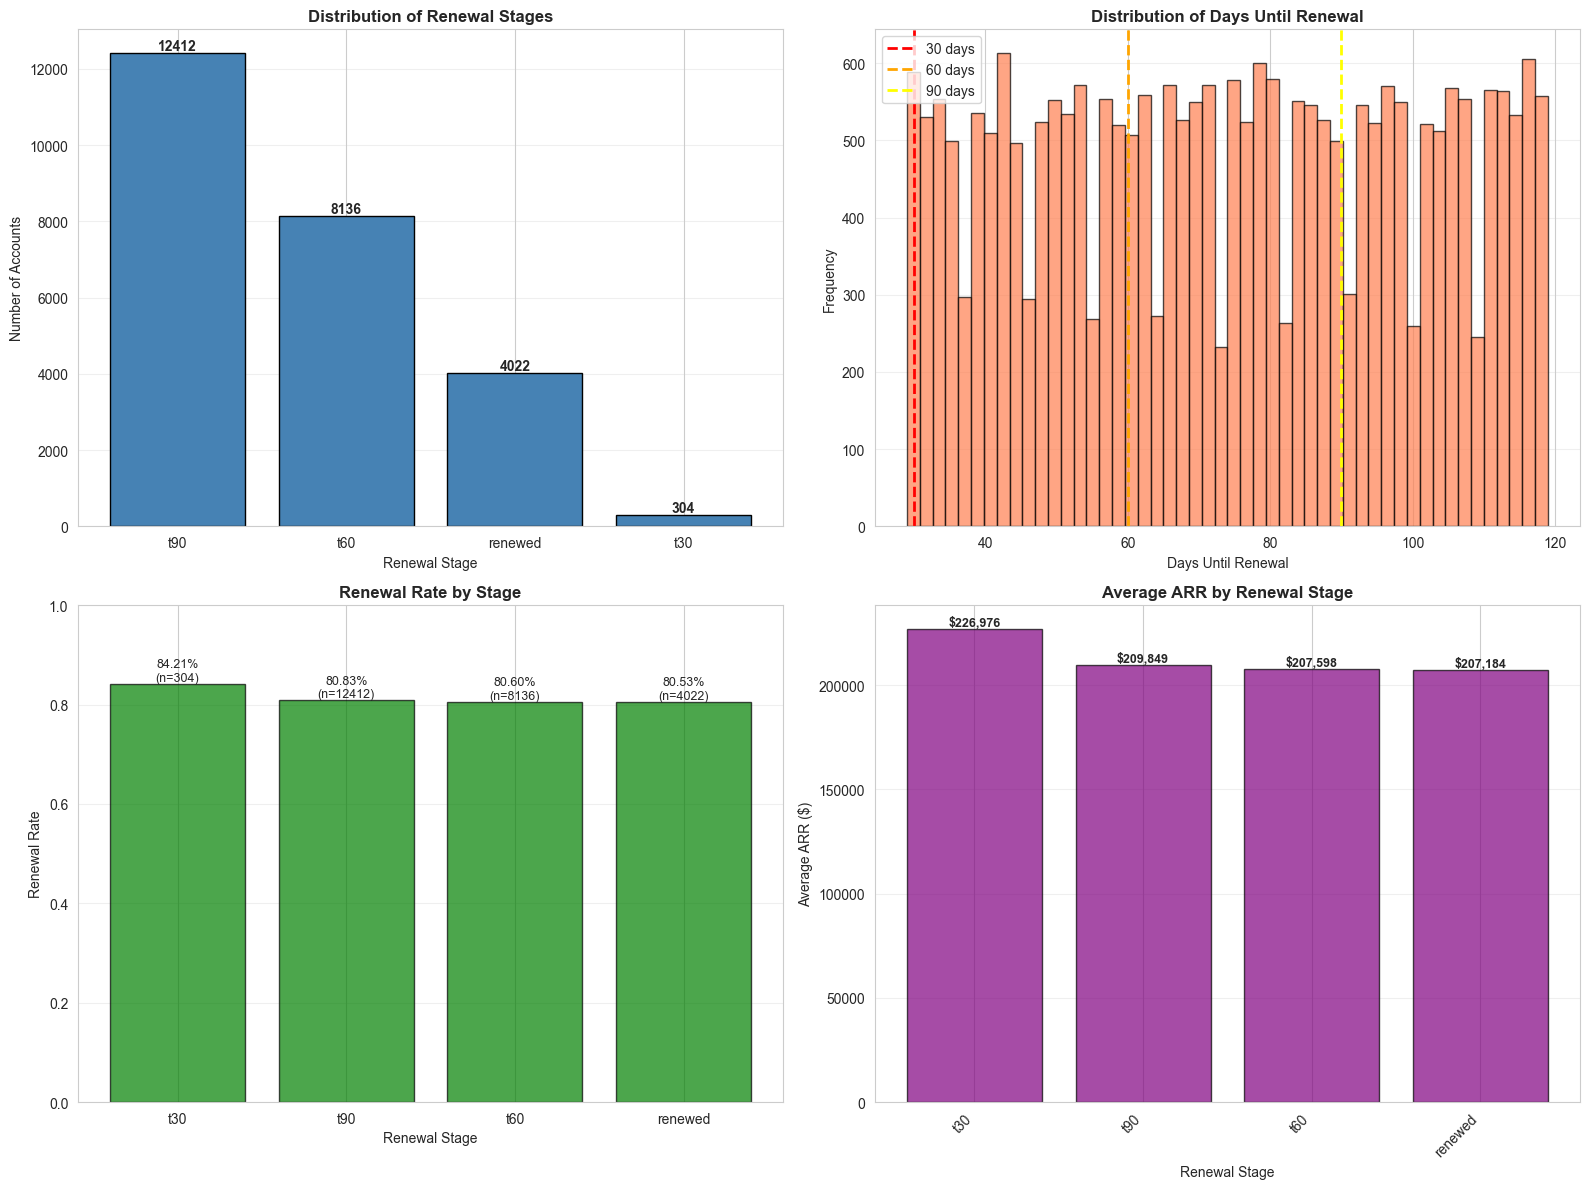

RENEWAL STAGE SUMMARY
                          Total Accounts  Renewals  Renewal Rate   Total ARR
renewal_stage_calculated                                                    
renewed                             4022      3239          0.81   833293871
t30                                  304       256          0.84    69000581
t60                                 8136      6558          0.81  1689020225
t90                                12412     10033          0.81  2604641512


In [19]:
# Analyze renewal stages
if 'renewal_stage_calculated' in df_renewal.columns:
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # 1. Renewal stage distribution
    stage_counts = df_renewal['renewal_stage_calculated'].value_counts()
    axes[0, 0].bar(stage_counts.index, stage_counts.values, color='steelblue', edgecolor='black')
    axes[0, 0].set_title('Distribution of Renewal Stages', fontsize=12, fontweight='bold')
    axes[0, 0].set_xlabel('Renewal Stage', fontsize=10)
    axes[0, 0].set_ylabel('Number of Accounts', fontsize=10)
    axes[0, 0].grid(True, alpha=0.3, axis='y')
    for i, v in enumerate(stage_counts.values):
        axes[0, 0].text(i, v, str(v), ha='center', va='bottom', fontweight='bold')
    
    # 2. Days until renewal distribution
    if 'days_until_renewal' in df_renewal.columns:
        valid_days = df_renewal['days_until_renewal'].dropna()
        axes[0, 1].hist(valid_days, bins=50, color='coral', edgecolor='black', alpha=0.7)
        axes[0, 1].axvline(30, color='red', linestyle='--', linewidth=2, label='30 days')
        axes[0, 1].axvline(60, color='orange', linestyle='--', linewidth=2, label='60 days')
        axes[0, 1].axvline(90, color='yellow', linestyle='--', linewidth=2, label='90 days')
        axes[0, 1].set_title('Distribution of Days Until Renewal', fontsize=12, fontweight='bold')
        axes[0, 1].set_xlabel('Days Until Renewal', fontsize=10)
        axes[0, 1].set_ylabel('Frequency', fontsize=10)
        axes[0, 1].legend()
        axes[0, 1].grid(True, alpha=0.3, axis='y')
    
    # 3. Renewal rate by stage (if target exists)
    if 'will_renew' in df_renewal.columns:
        renewal_by_stage = df_renewal.groupby('renewal_stage_calculated')['will_renew'].agg(['mean', 'count'])
        renewal_by_stage.columns = ['Renewal Rate', 'Count']
        renewal_by_stage = renewal_by_stage.sort_values('Renewal Rate', ascending=False)
        
        bars = axes[1, 0].bar(renewal_by_stage.index, renewal_by_stage['Renewal Rate'], 
                              color='green', edgecolor='black', alpha=0.7)
        axes[1, 0].set_title('Renewal Rate by Stage', fontsize=12, fontweight='bold')
        axes[1, 0].set_xlabel('Renewal Stage', fontsize=10)
        axes[1, 0].set_ylabel('Renewal Rate', fontsize=10)
        axes[1, 0].set_ylim([0, 1])
        axes[1, 0].grid(True, alpha=0.3, axis='y')
        for i, (idx, row) in enumerate(renewal_by_stage.iterrows()):
            axes[1, 0].text(i, row['Renewal Rate'], f"{row['Renewal Rate']:.2%}\n(n={int(row['Count'])})", 
                           ha='center', va='bottom', fontsize=9)
    
    # 4. ARR by renewal stage
    if 'arr' in df_renewal.columns and 'renewal_stage_calculated' in df_renewal.columns:
        arr_by_stage = df_renewal.groupby('renewal_stage_calculated')['arr'].agg(['mean', 'sum', 'count'])
        arr_by_stage.columns = ['Mean ARR', 'Total ARR', 'Count']
        arr_by_stage = arr_by_stage.sort_values('Mean ARR', ascending=False)
        
        x_pos = np.arange(len(arr_by_stage))
        axes[1, 1].bar(x_pos, arr_by_stage['Mean ARR'], color='purple', edgecolor='black', alpha=0.7)
        axes[1, 1].set_title('Average ARR by Renewal Stage', fontsize=12, fontweight='bold')
        axes[1, 1].set_xlabel('Renewal Stage', fontsize=10)
        axes[1, 1].set_ylabel('Average ARR ($)', fontsize=10)
        axes[1, 1].set_xticks(x_pos)
        axes[1, 1].set_xticklabels(arr_by_stage.index, rotation=45, ha='right')
        axes[1, 1].grid(True, alpha=0.3, axis='y')
        for i, (idx, row) in enumerate(arr_by_stage.iterrows()):
            axes[1, 1].text(i, row['Mean ARR'], f"${row['Mean ARR']:,.0f}", 
                           ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    print("=" * 80)
    print("RENEWAL STAGE SUMMARY")
    print("=" * 80)
    if 'will_renew' in df_renewal.columns:
        summary = df_renewal.groupby('renewal_stage_calculated').agg({
            'will_renew': ['count', 'sum', 'mean'],
            'arr': 'sum' if 'arr' in df_renewal.columns else lambda x: 0
        }).round(2)
        if 'arr' in df_renewal.columns:
            summary.columns = ['Total Accounts', 'Renewals', 'Renewal Rate', 'Total ARR']
        else:
            summary.columns = ['Total Accounts', 'Renewals', 'Renewal Rate']
        print(summary)

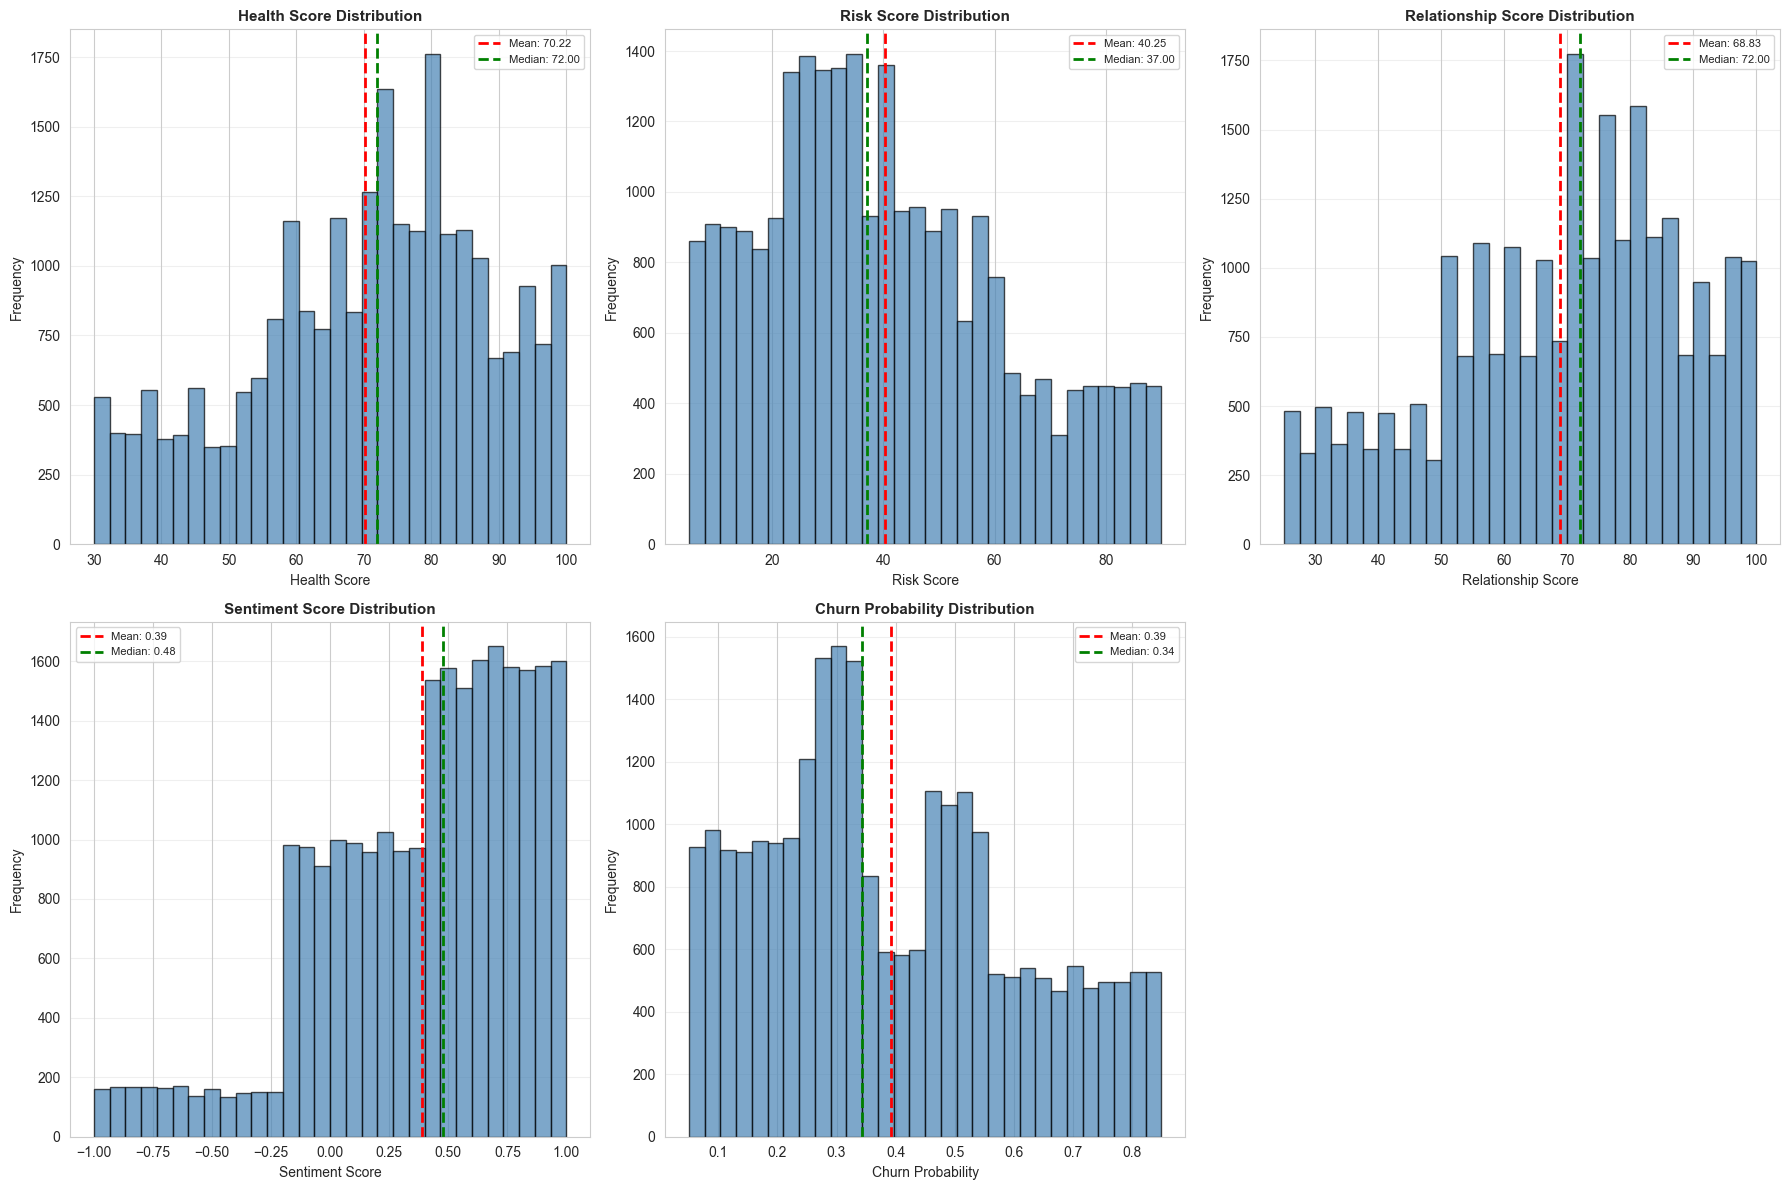

CORRELATION WITH RENEWAL
           Feature  Correlation with Renewal
      health_score                  0.553580
relationship_score                  0.539569
   sentiment_score                  0.497088
 churn_probability                 -0.694445
        risk_score                 -0.697959


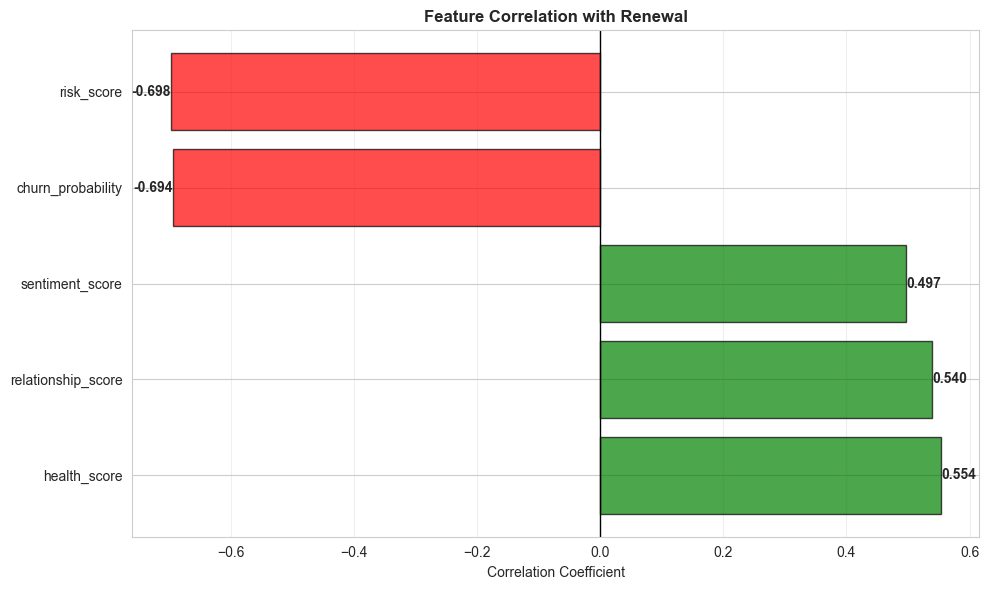

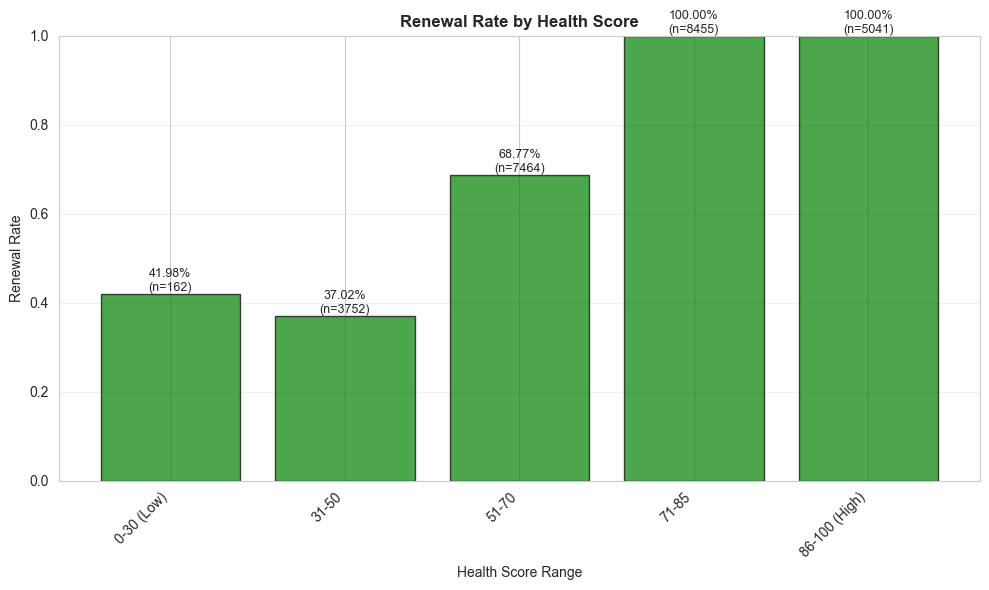

In [20]:
# Analyze health and risk scores
health_features = ['health_score', 'risk_score', 'relationship_score', 'sentiment_score', 'churn_probability']
available_health = [f for f in health_features if f in df_renewal.columns]

if available_health:
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    axes = axes.flatten()
    
    for idx, feature in enumerate(available_health[:6]):  # Limit to 6 features
        ax = axes[idx]
        
        # Distribution
        if df_renewal[feature].dtype in ['int64', 'float64']:
            ax.hist(df_renewal[feature].dropna(), bins=30, color='steelblue', edgecolor='black', alpha=0.7)
            ax.set_title(f'{feature.replace("_", " ").title()} Distribution', fontsize=11, fontweight='bold')
            ax.set_xlabel(feature.replace("_", " ").title(), fontsize=10)
            ax.set_ylabel('Frequency', fontsize=10)
            ax.grid(True, alpha=0.3, axis='y')
            
            # Add statistics
            mean_val = df_renewal[feature].mean()
            median_val = df_renewal[feature].median()
            ax.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.2f}')
            ax.axvline(median_val, color='green', linestyle='--', linewidth=2, label=f'Median: {median_val:.2f}')
            ax.legend(fontsize=8)
    
    # Hide unused subplots
    for idx in range(len(available_health), 6):
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Correlation with renewal (if target exists)
    if 'will_renew' in df_renewal.columns:
        print("=" * 80)
        print("CORRELATION WITH RENEWAL")
        print("=" * 80)
        correlations = {}
        for feature in available_health:
            if df_renewal[feature].dtype in ['int64', 'float64']:
                corr = df_renewal[feature].corr(df_renewal['will_renew'])
                correlations[feature] = corr
        
        corr_df = pd.DataFrame(list(correlations.items()), columns=['Feature', 'Correlation with Renewal'])
        corr_df = corr_df.sort_values('Correlation with Renewal', ascending=False)
        print(corr_df.to_string(index=False))
        
        # Visualize correlations
        fig, ax = plt.subplots(1, 1, figsize=(10, 6))
        colors = ['green' if x > 0 else 'red' for x in corr_df['Correlation with Renewal']]
        bars = ax.barh(corr_df['Feature'], corr_df['Correlation with Renewal'], color=colors, alpha=0.7, edgecolor='black')
        ax.set_title('Feature Correlation with Renewal', fontsize=12, fontweight='bold')
        ax.set_xlabel('Correlation Coefficient', fontsize=10)
        ax.axvline(0, color='black', linestyle='-', linewidth=1)
        ax.grid(True, alpha=0.3, axis='x')
        for i, (idx, row) in enumerate(corr_df.iterrows()):
            ax.text(row['Correlation with Renewal'], i, f"{row['Correlation with Renewal']:.3f}", 
                   va='center', ha='left' if row['Correlation with Renewal'] > 0 else 'right', fontweight='bold')
        plt.tight_layout()
        plt.show()
    
    # Renewal rate by health score bins
    if 'health_score' in df_renewal.columns and 'will_renew' in df_renewal.columns:
        df_renewal['health_score_bin'] = pd.cut(df_renewal['health_score'], 
                                                bins=[0, 30, 50, 70, 85, 100], 
                                                labels=['0-30 (Low)', '31-50', '51-70', '71-85', '86-100 (High)'])
        
        health_renewal = df_renewal.groupby('health_score_bin')['will_renew'].agg(['mean', 'count'])
        health_renewal.columns = ['Renewal Rate', 'Count']
        
        fig, ax = plt.subplots(1, 1, figsize=(10, 6))
        bars = ax.bar(range(len(health_renewal)), health_renewal['Renewal Rate'], 
                     color='green', edgecolor='black', alpha=0.7)
        ax.set_title('Renewal Rate by Health Score', fontsize=12, fontweight='bold')
        ax.set_xlabel('Health Score Range', fontsize=10)
        ax.set_ylabel('Renewal Rate', fontsize=10)
        ax.set_xticks(range(len(health_renewal)))
        ax.set_xticklabels(health_renewal.index, rotation=45, ha='right')
        ax.set_ylim([0, 1])
        ax.grid(True, alpha=0.3, axis='y')
        for i, (idx, row) in enumerate(health_renewal.iterrows()):
            ax.text(i, row['Renewal Rate'], f"{row['Renewal Rate']:.2%}\n(n={int(row['Count'])})", 
                   ha='center', va='bottom', fontsize=9)
        plt.tight_layout()
        plt.show()

## 5. Churn Probability & Renewal Relationship

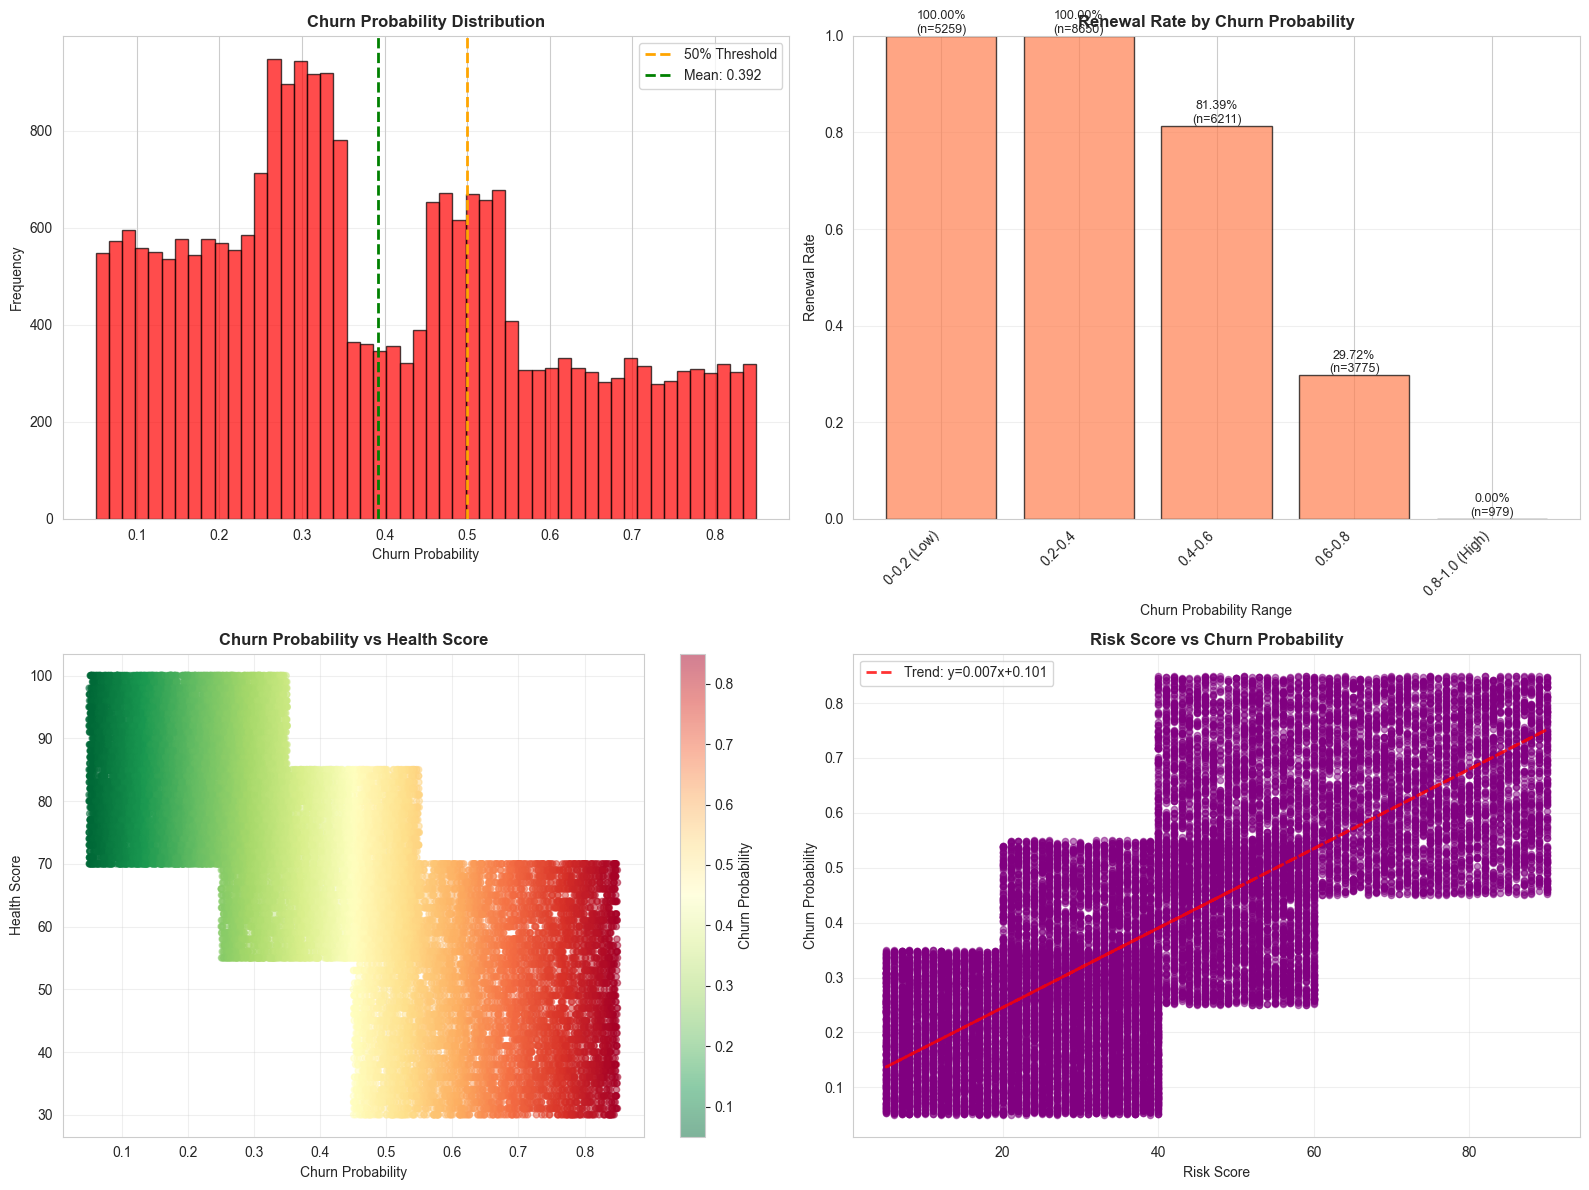

CHURN PROBABILITY ANALYSIS
Mean Churn Probability: 0.3919
Median Churn Probability: 0.3439
Std Churn Probability: 0.2131

High Churn Risk (>0.5): 7,832 accounts
  Renewal Rate: 43.56%
Low Churn Risk (≤0.5): 17,042 accounts
  Renewal Rate: 97.84%


In [21]:
# Analyze churn probability and its relationship with renewal
if 'churn_probability' in df_renewal.columns:
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # 1. Churn probability distribution
    axes[0, 0].hist(df_renewal['churn_probability'].dropna(), bins=50, color='red', edgecolor='black', alpha=0.7)
    axes[0, 0].set_title('Churn Probability Distribution', fontsize=12, fontweight='bold')
    axes[0, 0].set_xlabel('Churn Probability', fontsize=10)
    axes[0, 0].set_ylabel('Frequency', fontsize=10)
    axes[0, 0].axvline(0.5, color='orange', linestyle='--', linewidth=2, label='50% Threshold')
    axes[0, 0].axvline(df_renewal['churn_probability'].mean(), color='green', linestyle='--', linewidth=2, 
                      label=f'Mean: {df_renewal["churn_probability"].mean():.3f}')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3, axis='y')
    
    # 2. Churn probability vs Renewal (if target exists)
    if 'will_renew' in df_renewal.columns:
        churn_bins = pd.cut(df_renewal['churn_probability'], bins=[0, 0.2, 0.4, 0.6, 0.8, 1.0],
                           labels=['0-0.2 (Low)', '0.2-0.4', '0.4-0.6', '0.6-0.8', '0.8-1.0 (High)'])
        churn_renewal = df_renewal.groupby(churn_bins)['will_renew'].agg(['mean', 'count'])
        churn_renewal.columns = ['Renewal Rate', 'Count']
        
        bars = axes[0, 1].bar(range(len(churn_renewal)), churn_renewal['Renewal Rate'], 
                             color='coral', edgecolor='black', alpha=0.7)
        axes[0, 1].set_title('Renewal Rate by Churn Probability', fontsize=12, fontweight='bold')
        axes[0, 1].set_xlabel('Churn Probability Range', fontsize=10)
        axes[0, 1].set_ylabel('Renewal Rate', fontsize=10)
        axes[0, 1].set_xticks(range(len(churn_renewal)))
        axes[0, 1].set_xticklabels(churn_renewal.index, rotation=45, ha='right')
        axes[0, 1].set_ylim([0, 1])
        axes[0, 1].grid(True, alpha=0.3, axis='y')
        for i, (idx, row) in enumerate(churn_renewal.iterrows()):
            axes[0, 1].text(i, row['Renewal Rate'], f"{row['Renewal Rate']:.2%}\n(n={int(row['Count'])})", 
                           ha='center', va='bottom', fontsize=9)
    
    # 3. Scatter: Churn Probability vs Health Score
    if 'health_score' in df_renewal.columns:
        scatter_data = df_renewal[['churn_probability', 'health_score']].dropna()
        if len(scatter_data) > 0:
            scatter = axes[1, 0].scatter(scatter_data['churn_probability'], scatter_data['health_score'],
                                        alpha=0.5, s=20, c=scatter_data['churn_probability'], cmap='RdYlGn_r')
            axes[1, 0].set_title('Churn Probability vs Health Score', fontsize=12, fontweight='bold')
            axes[1, 0].set_xlabel('Churn Probability', fontsize=10)
            axes[1, 0].set_ylabel('Health Score', fontsize=10)
            axes[1, 0].grid(True, alpha=0.3)
            plt.colorbar(scatter, ax=axes[1, 0], label='Churn Probability')
    
    # 4. Risk Score vs Churn Probability
    if 'risk_score' in df_renewal.columns:
        risk_churn = df_renewal[['risk_score', 'churn_probability']].dropna()
        if len(risk_churn) > 0:
            axes[1, 1].scatter(risk_churn['risk_score'], risk_churn['churn_probability'],
                              alpha=0.5, s=20, color='purple')
            axes[1, 1].set_title('Risk Score vs Churn Probability', fontsize=12, fontweight='bold')
            axes[1, 1].set_xlabel('Risk Score', fontsize=10)
            axes[1, 1].set_ylabel('Churn Probability', fontsize=10)
            axes[1, 1].grid(True, alpha=0.3)
            
            # Add trend line
            z = np.polyfit(risk_churn['risk_score'], risk_churn['churn_probability'], 1)
            p = np.poly1d(z)
            axes[1, 1].plot(risk_churn['risk_score'], p(risk_churn['risk_score']), 
                          "r--", alpha=0.8, linewidth=2, label=f'Trend: y={z[0]:.3f}x+{z[1]:.3f}')
            axes[1, 1].legend()
    
    plt.tight_layout()
    plt.show()
    
    # Summary statistics
    print("=" * 80)
    print("CHURN PROBABILITY ANALYSIS")
    print("=" * 80)
    print(f"Mean Churn Probability: {df_renewal['churn_probability'].mean():.4f}")
    print(f"Median Churn Probability: {df_renewal['churn_probability'].median():.4f}")
    print(f"Std Churn Probability: {df_renewal['churn_probability'].std():.4f}")
    
    if 'will_renew' in df_renewal.columns:
        high_churn = df_renewal[df_renewal['churn_probability'] > 0.5]
        low_churn = df_renewal[df_renewal['churn_probability'] <= 0.5]
        print(f"\nHigh Churn Risk (>0.5): {len(high_churn):,} accounts")
        if len(high_churn) > 0:
            print(f"  Renewal Rate: {high_churn['will_renew'].mean():.2%}")
        print(f"Low Churn Risk (≤0.5): {len(low_churn):,} accounts")
        if len(low_churn) > 0:
            print(f"  Renewal Rate: {low_churn['will_renew'].mean():.2%}")

## 6. Utilization & Contract Analysis

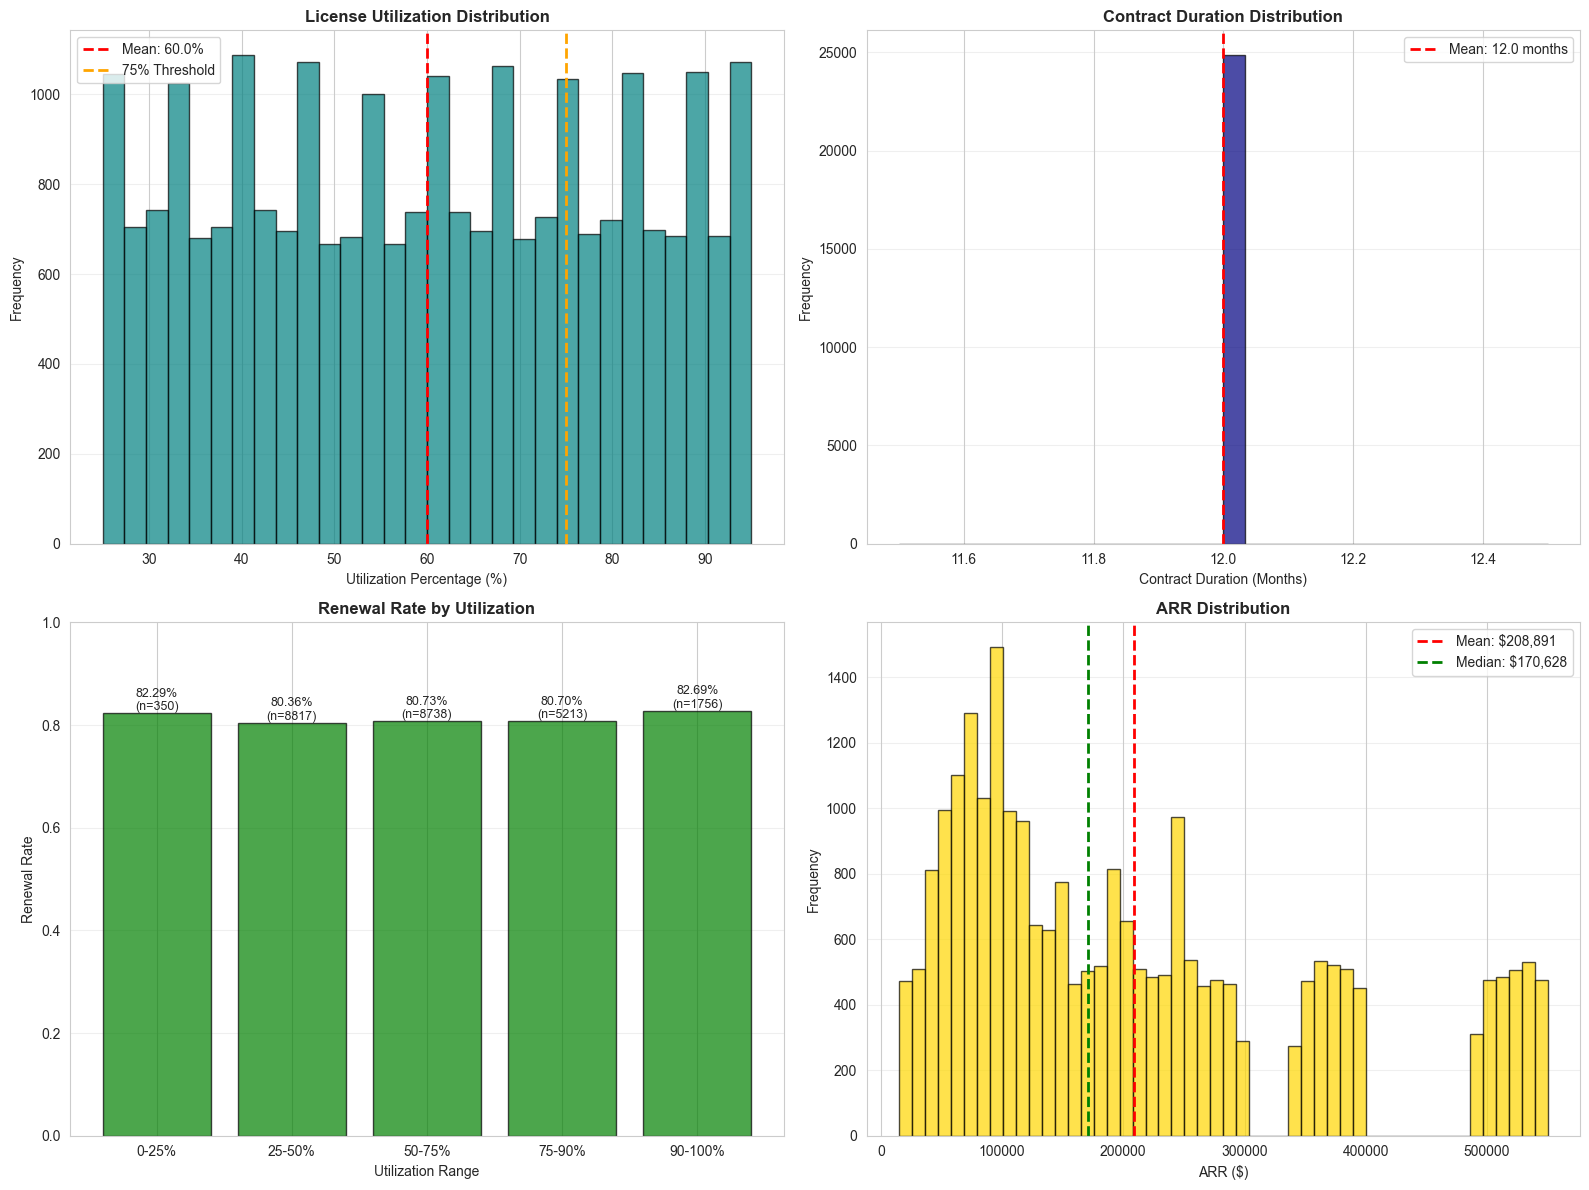

UTILIZATION & CONTRACT SUMMARY

Utilization Percentage:
  Mean: 59.96
  Median: 60.00
  Std: 20.50
  Min: 25.00
  Max: 95.00

Contract Duration Months:
  Mean: 12.00
  Median: 12.00
  Std: 0.00
  Min: 12.00
  Max: 12.00

Arr:
  Mean: 208891.06
  Median: 170628.00
  Std: 148417.19
  Min: 15019.00
  Max: 549999.00

Mrr:
  Mean: 17407.59
  Median: 14219.00
  Std: 12368.10
  Min: 1251.58
  Max: 45833.25


In [22]:
# Analyze utilization and contract features
utilization_features = ['utilization_percentage', 'contract_duration_months', 'arr', 'mrr']
available_util = [f for f in utilization_features if f in df_renewal.columns]

if available_util:
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # 1. Utilization percentage distribution
    if 'utilization_percentage' in df_renewal.columns:
        util_data = df_renewal['utilization_percentage'].dropna()
        axes[0, 0].hist(util_data, bins=30, color='teal', edgecolor='black', alpha=0.7)
        axes[0, 0].axvline(util_data.mean(), color='red', linestyle='--', linewidth=2, 
                          label=f'Mean: {util_data.mean():.1f}%')
        axes[0, 0].axvline(75, color='orange', linestyle='--', linewidth=2, label='75% Threshold')
        axes[0, 0].set_title('License Utilization Distribution', fontsize=12, fontweight='bold')
        axes[0, 0].set_xlabel('Utilization Percentage (%)', fontsize=10)
        axes[0, 0].set_ylabel('Frequency', fontsize=10)
        axes[0, 0].legend()
        axes[0, 0].grid(True, alpha=0.3, axis='y')
    
    # 2. Contract duration
    if 'contract_duration_months' in df_renewal.columns:
        contract_data = df_renewal['contract_duration_months'].dropna()
        axes[0, 1].hist(contract_data, bins=30, color='navy', edgecolor='black', alpha=0.7)
        axes[0, 1].axvline(contract_data.mean(), color='red', linestyle='--', linewidth=2,
                          label=f'Mean: {contract_data.mean():.1f} months')
        axes[0, 1].set_title('Contract Duration Distribution', fontsize=12, fontweight='bold')
        axes[0, 1].set_xlabel('Contract Duration (Months)', fontsize=10)
        axes[0, 1].set_ylabel('Frequency', fontsize=10)
        axes[0, 1].legend()
        axes[0, 1].grid(True, alpha=0.3, axis='y')
    
    # 3. Utilization vs Renewal (if target exists)
    if 'utilization_percentage' in df_renewal.columns and 'will_renew' in df_renewal.columns:
        util_bins = pd.cut(df_renewal['utilization_percentage'], 
                          bins=[0, 25, 50, 75, 90, 100],
                          labels=['0-25%', '25-50%', '50-75%', '75-90%', '90-100%'])
        util_renewal = df_renewal.groupby(util_bins)['will_renew'].agg(['mean', 'count'])
        util_renewal.columns = ['Renewal Rate', 'Count']
        
        bars = axes[1, 0].bar(range(len(util_renewal)), util_renewal['Renewal Rate'],
                             color='green', edgecolor='black', alpha=0.7)
        axes[1, 0].set_title('Renewal Rate by Utilization', fontsize=12, fontweight='bold')
        axes[1, 0].set_xlabel('Utilization Range', fontsize=10)
        axes[1, 0].set_ylabel('Renewal Rate', fontsize=10)
        axes[1, 0].set_xticks(range(len(util_renewal)))
        axes[1, 0].set_xticklabels(util_renewal.index)
        axes[1, 0].set_ylim([0, 1])
        axes[1, 0].grid(True, alpha=0.3, axis='y')
        for i, (idx, row) in enumerate(util_renewal.iterrows()):
            axes[1, 0].text(i, row['Renewal Rate'], f"{row['Renewal Rate']:.2%}\n(n={int(row['Count'])})",
                           ha='center', va='bottom', fontsize=9)
    
    # 4. ARR distribution
    if 'arr' in df_renewal.columns:
        arr_data = df_renewal['arr'].dropna()
        # Use log scale for better visualization if ARR has wide range
        axes[1, 1].hist(arr_data, bins=50, color='gold', edgecolor='black', alpha=0.7)
        axes[1, 1].set_title('ARR Distribution', fontsize=12, fontweight='bold')
        axes[1, 1].set_xlabel('ARR ($)', fontsize=10)
        axes[1, 1].set_ylabel('Frequency', fontsize=10)
        axes[1, 1].axvline(arr_data.mean(), color='red', linestyle='--', linewidth=2,
                          label=f'Mean: ${arr_data.mean():,.0f}')
        axes[1, 1].axvline(arr_data.median(), color='green', linestyle='--', linewidth=2,
                          label=f'Median: ${arr_data.median():,.0f}')
        axes[1, 1].legend()
        axes[1, 1].grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
    
    # Summary statistics
    print("=" * 80)
    print("UTILIZATION & CONTRACT SUMMARY")
    print("=" * 80)
    for feature in available_util:
        if feature in df_renewal.columns:
            data = df_renewal[feature].dropna()
            print(f"\n{feature.replace('_', ' ').title()}:")
            print(f"  Mean: {data.mean():.2f}")
            print(f"  Median: {data.median():.2f}")
            print(f"  Std: {data.std():.2f}")
            print(f"  Min: {data.min():.2f}")
            print(f"  Max: {data.max():.2f}")

## 7. Relationship & Sentiment Analysis

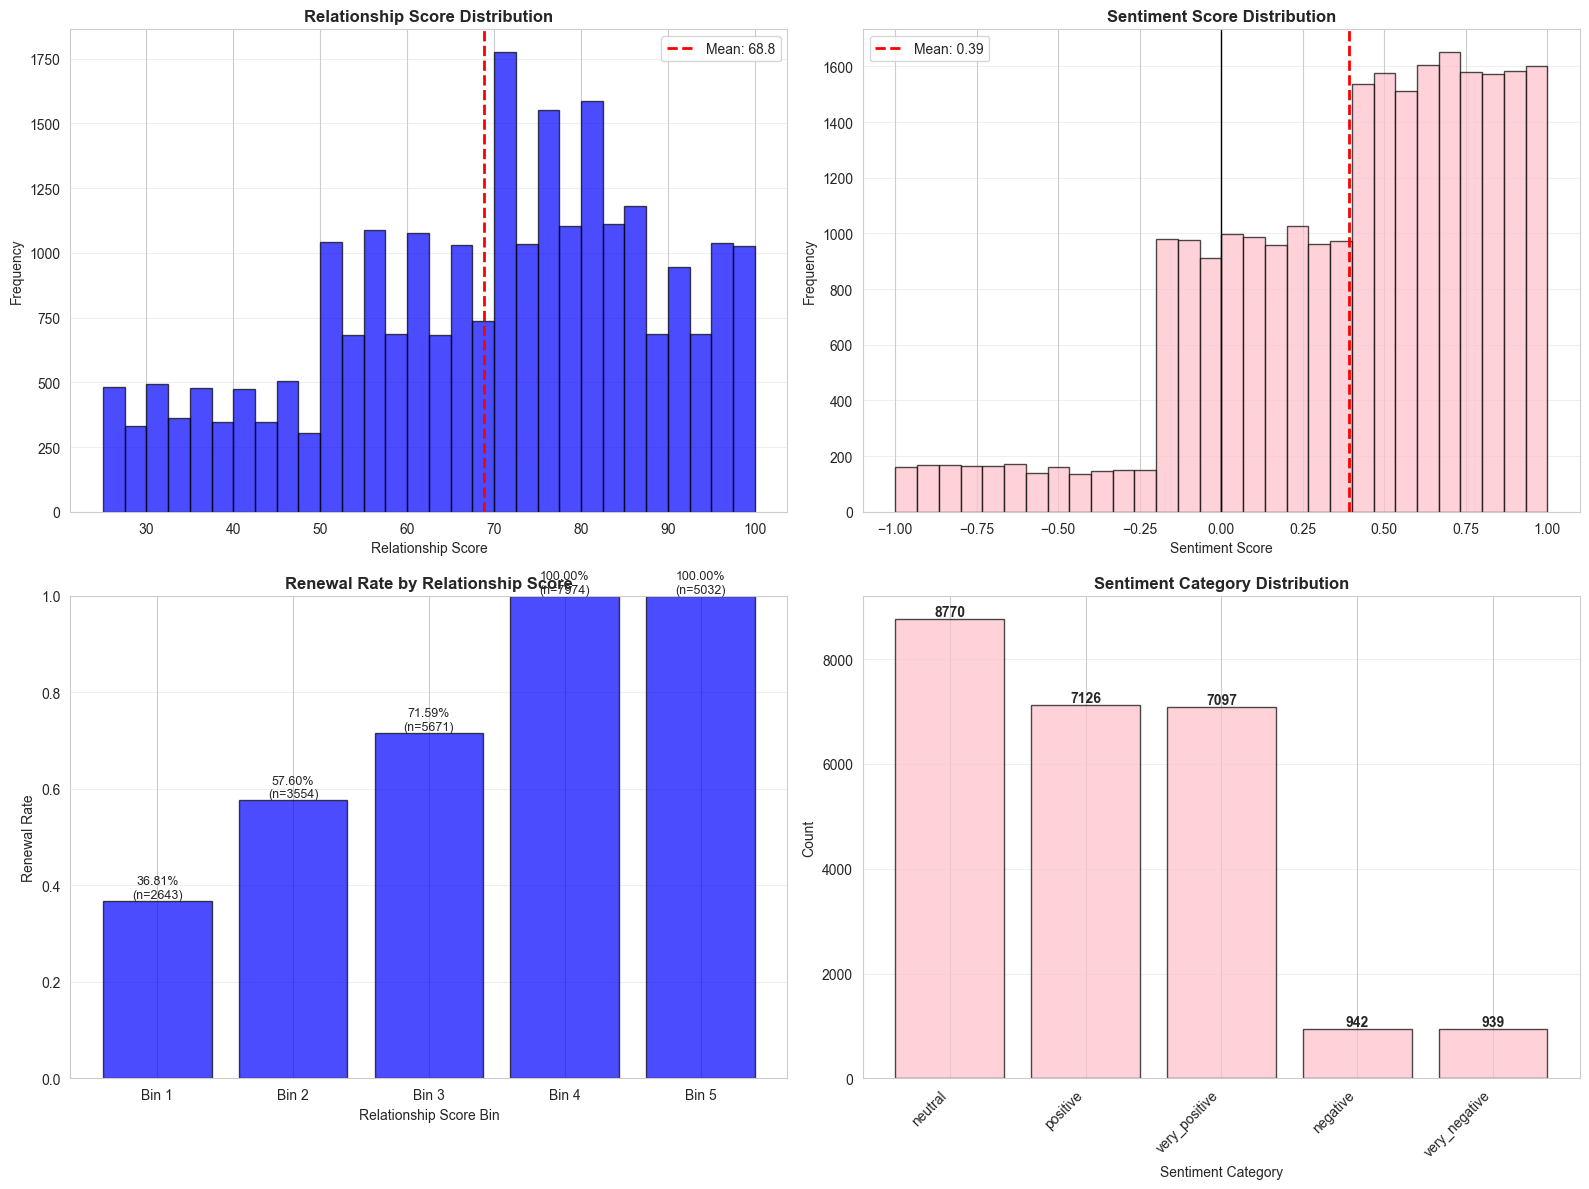

RELATIONSHIP & SENTIMENT CORRELATION
Correlation between Relationship Score and Sentiment Score: 0.6031

Correlation with Renewal:
  Relationship Score: 0.5396
  Sentiment Score: 0.4971


In [23]:
# Analyze relationship and sentiment scores
if 'relationship_score' in df_renewal.columns or 'sentiment_score' in df_renewal.columns:
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # 1. Relationship score distribution
    if 'relationship_score' in df_renewal.columns:
        rel_data = df_renewal['relationship_score'].dropna()
        axes[0, 0].hist(rel_data, bins=30, color='blue', edgecolor='black', alpha=0.7)
        axes[0, 0].axvline(rel_data.mean(), color='red', linestyle='--', linewidth=2,
                         label=f'Mean: {rel_data.mean():.1f}')
        axes[0, 0].set_title('Relationship Score Distribution', fontsize=12, fontweight='bold')
        axes[0, 0].set_xlabel('Relationship Score', fontsize=10)
        axes[0, 0].set_ylabel('Frequency', fontsize=10)
        axes[0, 0].legend()
        axes[0, 0].grid(True, alpha=0.3, axis='y')
    
    # 2. Sentiment score distribution
    if 'sentiment_score' in df_renewal.columns:
        sent_data = df_renewal['sentiment_score'].dropna()
        axes[0, 1].hist(sent_data, bins=30, color='pink', edgecolor='black', alpha=0.7)
        axes[0, 1].axvline(sent_data.mean(), color='red', linestyle='--', linewidth=2,
                          label=f'Mean: {sent_data.mean():.2f}')
        axes[0, 1].axvline(0, color='black', linestyle='-', linewidth=1)
        axes[0, 1].set_title('Sentiment Score Distribution', fontsize=12, fontweight='bold')
        axes[0, 1].set_xlabel('Sentiment Score', fontsize=10)
        axes[0, 1].set_ylabel('Frequency', fontsize=10)
        axes[0, 1].legend()
        axes[0, 1].grid(True, alpha=0.3, axis='y')
    
    # 3. Relationship score vs Renewal
    if 'relationship_score' in df_renewal.columns and 'will_renew' in df_renewal.columns:
        rel_bins = pd.cut(df_renewal['relationship_score'], bins=5, labels=False)
        rel_renewal = df_renewal.groupby(rel_bins)['will_renew'].agg(['mean', 'count'])
        rel_renewal.columns = ['Renewal Rate', 'Count']
        
        bars = axes[1, 0].bar(range(len(rel_renewal)), rel_renewal['Renewal Rate'],
                             color='blue', edgecolor='black', alpha=0.7)
        axes[1, 0].set_title('Renewal Rate by Relationship Score', fontsize=12, fontweight='bold')
        axes[1, 0].set_xlabel('Relationship Score Bin', fontsize=10)
        axes[1, 0].set_ylabel('Renewal Rate', fontsize=10)
        axes[1, 0].set_xticks(range(len(rel_renewal)))
        axes[1, 0].set_xticklabels([f'Bin {i+1}' for i in range(len(rel_renewal))])
        axes[1, 0].set_ylim([0, 1])
        axes[1, 0].grid(True, alpha=0.3, axis='y')
        for i, (idx, row) in enumerate(rel_renewal.iterrows()):
            axes[1, 0].text(i, row['Renewal Rate'], f"{row['Renewal Rate']:.2%}\n(n={int(row['Count'])})",
                           ha='center', va='bottom', fontsize=9)
    
    # 4. Sentiment category distribution (if exists)
    if 'sentiment_category' in df_renewal.columns:
        sent_cat_counts = df_renewal['sentiment_category'].value_counts()
        axes[1, 1].bar(range(len(sent_cat_counts)), sent_cat_counts.values,
                     color='pink', edgecolor='black', alpha=0.7)
        axes[1, 1].set_title('Sentiment Category Distribution', fontsize=12, fontweight='bold')
        axes[1, 1].set_xlabel('Sentiment Category', fontsize=10)
        axes[1, 1].set_ylabel('Count', fontsize=10)
        axes[1, 1].set_xticks(range(len(sent_cat_counts)))
        axes[1, 1].set_xticklabels(sent_cat_counts.index, rotation=45, ha='right')
        axes[1, 1].grid(True, alpha=0.3, axis='y')
        for i, v in enumerate(sent_cat_counts.values):
            axes[1, 1].text(i, v, str(v), ha='center', va='bottom', fontweight='bold')
    elif 'sentiment_score' in df_renewal.columns and 'will_renew' in df_renewal.columns:
        # Sentiment vs Renewal
        sent_bins = pd.cut(df_renewal['sentiment_score'], bins=5, labels=False)
        sent_renewal = df_renewal.groupby(sent_bins)['will_renew'].agg(['mean', 'count'])
        sent_renewal.columns = ['Renewal Rate', 'Count']
        
        bars = axes[1, 1].bar(range(len(sent_renewal)), sent_renewal['Renewal Rate'],
                            color='pink', edgecolor='black', alpha=0.7)
        axes[1, 1].set_title('Renewal Rate by Sentiment Score', fontsize=12, fontweight='bold')
        axes[1, 1].set_xlabel('Sentiment Score Bin', fontsize=10)
        axes[1, 1].set_ylabel('Renewal Rate', fontsize=10)
        axes[1, 1].set_xticks(range(len(sent_renewal)))
        axes[1, 1].set_xticklabels([f'Bin {i+1}' for i in range(len(sent_renewal))])
        axes[1, 1].set_ylim([0, 1])
        axes[1, 1].grid(True, alpha=0.3, axis='y')
        for i, (idx, row) in enumerate(sent_renewal.iterrows()):
            axes[1, 1].text(i, row['Renewal Rate'], f"{row['Renewal Rate']:.2%}\n(n={int(row['Count'])})",
                           ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    plt.show()
    
    # Correlation analysis
    if 'relationship_score' in df_renewal.columns and 'sentiment_score' in df_renewal.columns:
        print("=" * 80)
        print("RELATIONSHIP & SENTIMENT CORRELATION")
        print("=" * 80)
        corr = df_renewal[['relationship_score', 'sentiment_score']].corr().iloc[0, 1]
        print(f"Correlation between Relationship Score and Sentiment Score: {corr:.4f}")
        
        if 'will_renew' in df_renewal.columns:
            rel_corr = df_renewal['relationship_score'].corr(df_renewal['will_renew'])
            sent_corr = df_renewal['sentiment_score'].corr(df_renewal['will_renew'])
            print(f"\nCorrelation with Renewal:")
            print(f"  Relationship Score: {rel_corr:.4f}")
            print(f"  Sentiment Score: {sent_corr:.4f}")

## 8. Feature Correlation Matrix

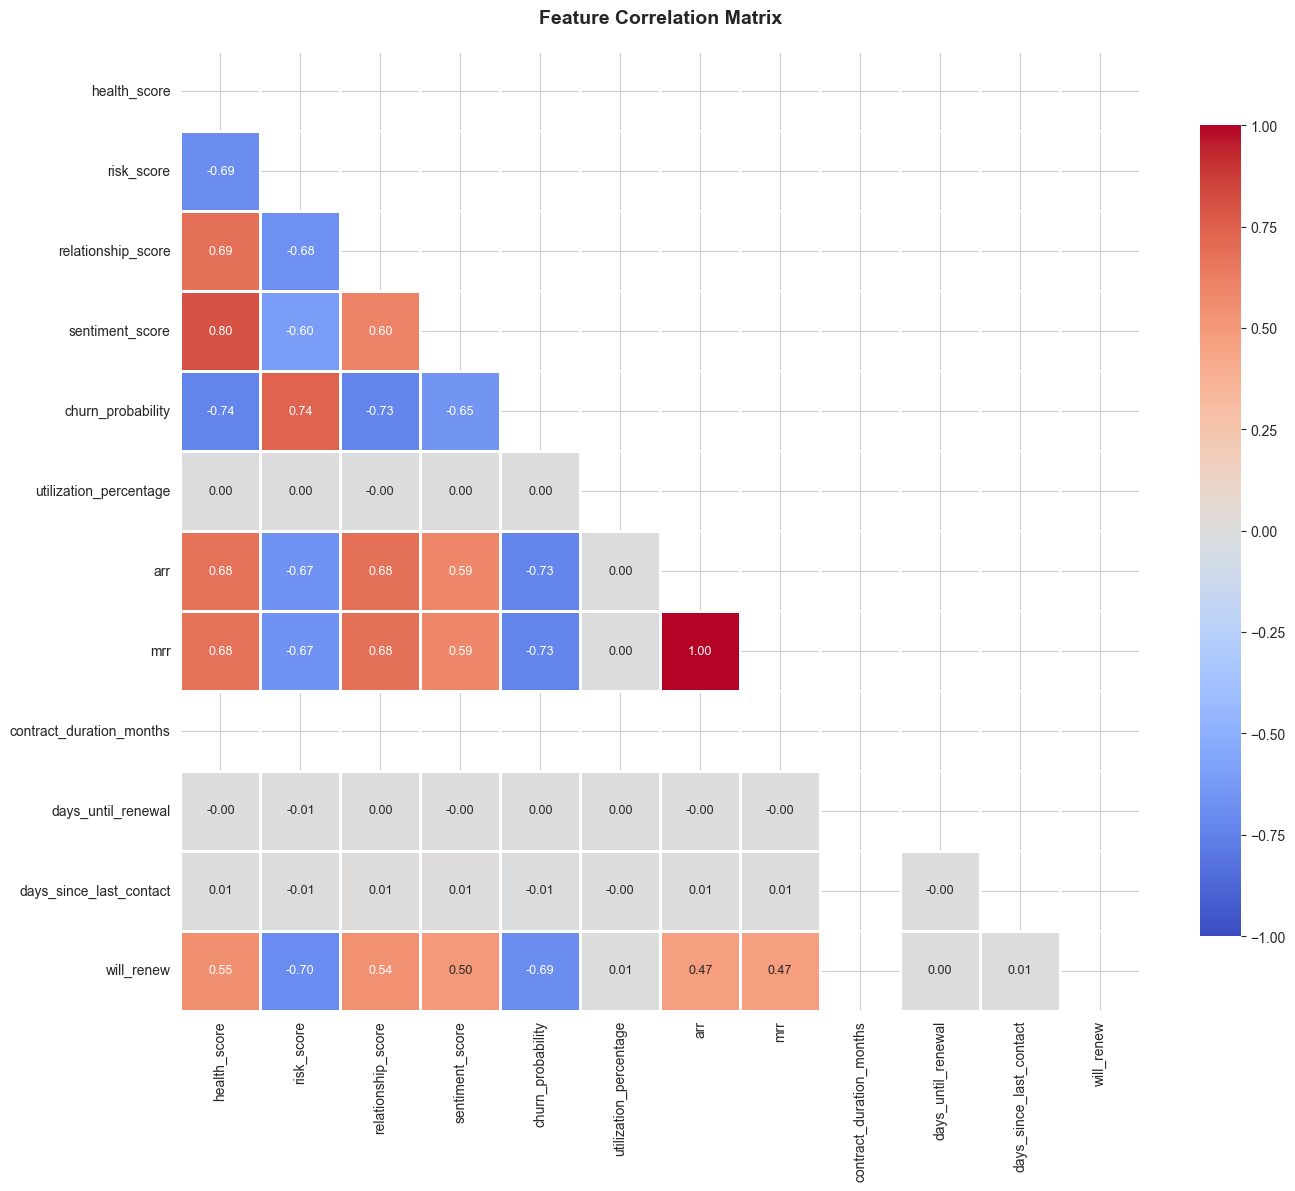

STRONG CORRELATIONS (|r| > 0.5)
         Feature 1          Feature 2  Correlation
               arr                mrr     1.000000
      health_score    sentiment_score     0.804332
      health_score  churn_probability    -0.742001
        risk_score  churn_probability     0.738006
relationship_score  churn_probability    -0.733938
 churn_probability                mrr    -0.731958
 churn_probability                arr    -0.731958
        risk_score         will_renew    -0.697959
 churn_probability         will_renew    -0.694445
      health_score         risk_score    -0.688734
      health_score relationship_score     0.687014
relationship_score                arr     0.681640
relationship_score                mrr     0.681640
        risk_score relationship_score    -0.679546
      health_score                arr     0.678701
      health_score                mrr     0.678701
        risk_score                arr    -0.671509
        risk_score                mrr    -0.671509

In [24]:
# Create correlation matrix for all numerical features
renewal_numerical_features = [
    'health_score', 'risk_score', 'relationship_score', 'sentiment_score',
    'churn_probability', 'utilization_percentage', 'arr', 'mrr',
    'contract_duration_months', 'days_until_renewal', 'days_since_last_contact'
]

available_numerical = [f for f in renewal_numerical_features if f in df_renewal.columns]

if len(available_numerical) > 1:
    # Add target if exists
    if 'will_renew' in df_renewal.columns:
        available_numerical.append('will_renew')
    
    corr_matrix = df_renewal[available_numerical].corr()
    
    # Create heatmap
    plt.figure(figsize=(14, 12))
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Mask upper triangle
    sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', 
                center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8},
                vmin=-1, vmax=1, annot_kws={'size': 9})
    plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.show()
    
    # Print strong correlations
    print("=" * 80)
    print("STRONG CORRELATIONS (|r| > 0.5)")
    print("=" * 80)
    strong_corr = []
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            corr_val = corr_matrix.iloc[i, j]
            if abs(corr_val) > 0.5 and not pd.isna(corr_val):
                strong_corr.append({
                    'Feature 1': corr_matrix.columns[i],
                    'Feature 2': corr_matrix.columns[j],
                    'Correlation': corr_val
                })
    
    if strong_corr:
        strong_corr_df = pd.DataFrame(strong_corr).sort_values('Correlation', key=abs, ascending=False)
        print(strong_corr_df.to_string(index=False))
    else:
        print("No strong correlations found (|r| > 0.5)")

## 9. Industry & Company Size Analysis

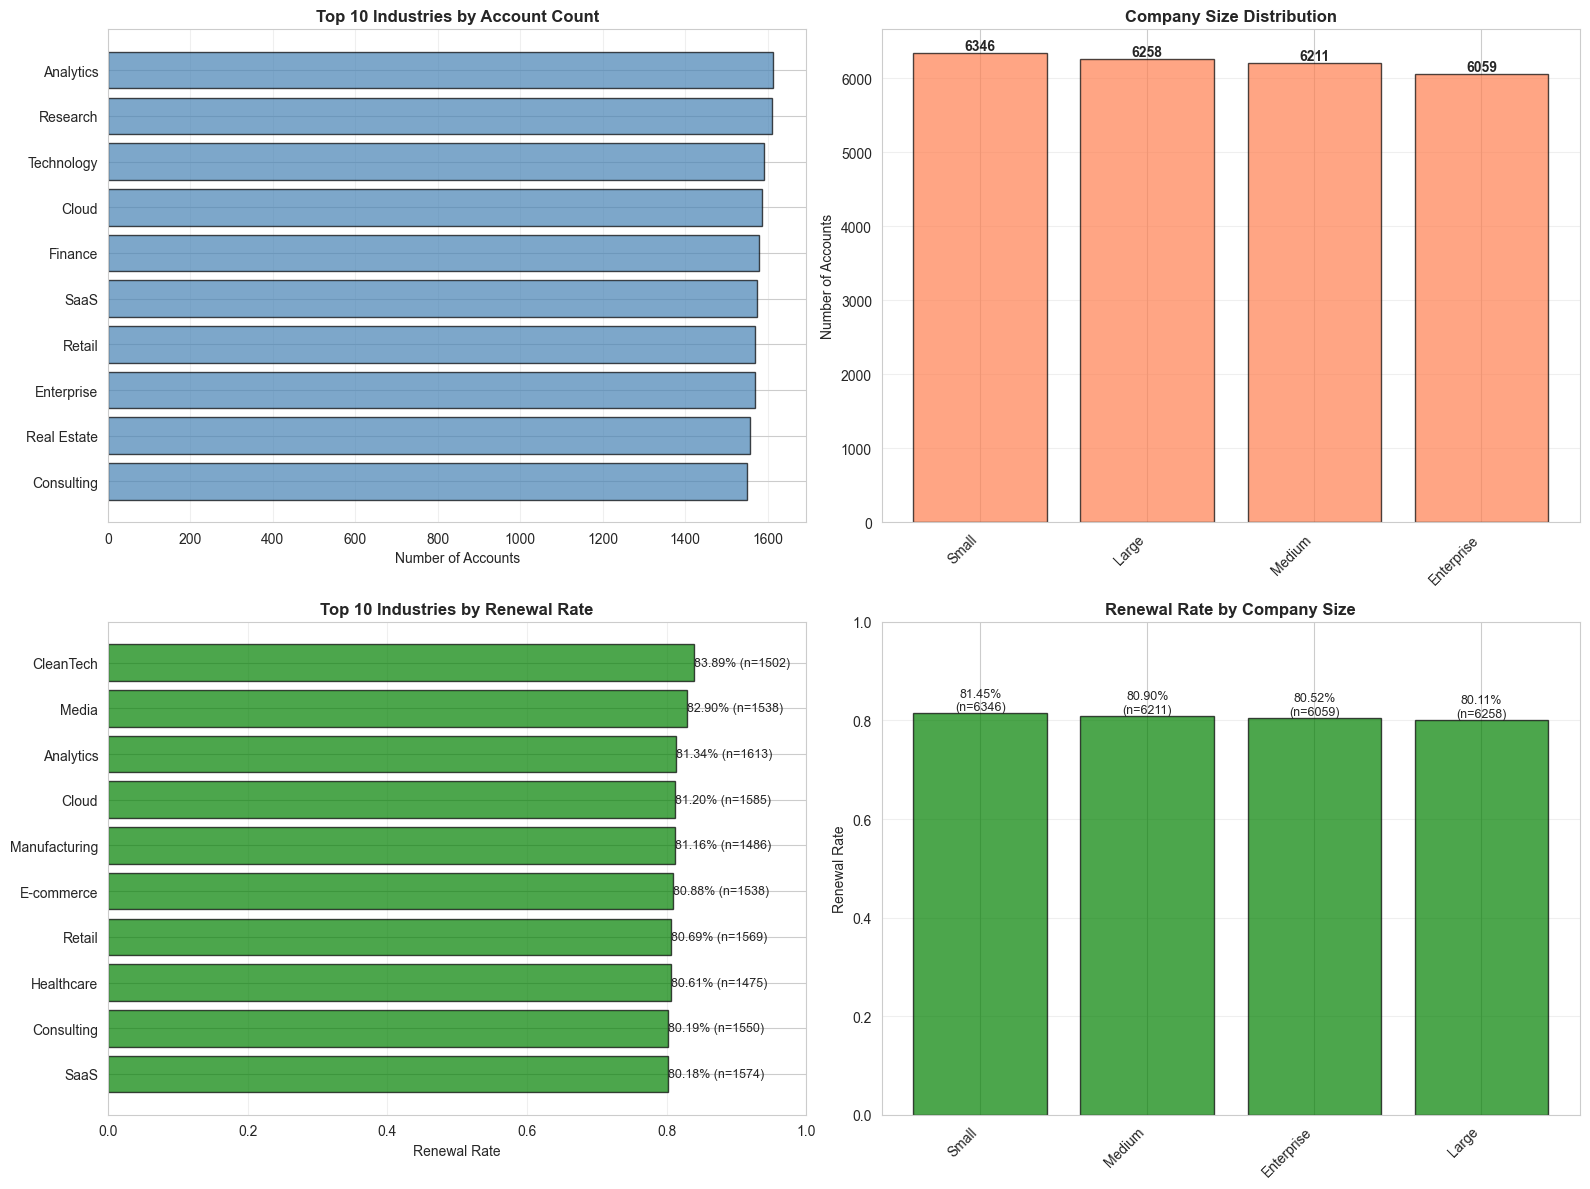

INDUSTRY & COMPANY SIZE SUMMARY

Renewal Rate by Industry:
               Renewal Rate  Count
industry                          
CleanTech          0.838881   1502
Media              0.828999   1538
Analytics          0.813391   1613
Cloud              0.811987   1585
Manufacturing      0.811575   1486
E-commerce         0.808843   1538
Retail             0.806883   1569
Healthcare         0.806102   1475
Consulting         0.801935   1550
SaaS               0.801779   1574
Technology         0.800251   1592
Research           0.800124   1611
Real Estate        0.799615   1557
Enterprise         0.797832   1568
Finance            0.797212   1578

Renewal Rate by Company Size:
              Renewal Rate  Count
company_size                     
Small             0.814529   6346
Medium            0.809048   6211
Enterprise        0.805248   6059
Large             0.801055   6258


In [25]:
# Analyze renewal patterns by industry and company size
categorical_features = ['industry', 'company_size']
available_categorical = [f for f in categorical_features if f in df_renewal.columns]

if available_categorical:
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # 1. Industry distribution
    if 'industry' in df_renewal.columns:
        industry_counts = df_renewal['industry'].value_counts().head(10)
        axes[0, 0].barh(range(len(industry_counts)), industry_counts.values,
                       color='steelblue', edgecolor='black', alpha=0.7)
        axes[0, 0].set_yticks(range(len(industry_counts)))
        axes[0, 0].set_yticklabels(industry_counts.index)
        axes[0, 0].set_title('Top 10 Industries by Account Count', fontsize=12, fontweight='bold')
        axes[0, 0].set_xlabel('Number of Accounts', fontsize=10)
        axes[0, 0].grid(True, alpha=0.3, axis='x')
        axes[0, 0].invert_yaxis()
    
    # 2. Company size distribution
    if 'company_size' in df_renewal.columns:
        size_counts = df_renewal['company_size'].value_counts()
        axes[0, 1].bar(range(len(size_counts)), size_counts.values,
                      color='coral', edgecolor='black', alpha=0.7)
        axes[0, 1].set_xticks(range(len(size_counts)))
        axes[0, 1].set_xticklabels(size_counts.index, rotation=45, ha='right')
        axes[0, 1].set_title('Company Size Distribution', fontsize=12, fontweight='bold')
        axes[0, 1].set_ylabel('Number of Accounts', fontsize=10)
        axes[0, 1].grid(True, alpha=0.3, axis='y')
        for i, v in enumerate(size_counts.values):
            axes[0, 1].text(i, v, str(v), ha='center', va='bottom', fontweight='bold')
    
    # 3. Renewal rate by industry (if target exists)
    if 'industry' in df_renewal.columns and 'will_renew' in df_renewal.columns:
        industry_renewal = df_renewal.groupby('industry')['will_renew'].agg(['mean', 'count']).sort_values('mean', ascending=False).head(10)
        industry_renewal.columns = ['Renewal Rate', 'Count']
        
        bars = axes[1, 0].barh(range(len(industry_renewal)), industry_renewal['Renewal Rate'],
                             color='green', edgecolor='black', alpha=0.7)
        axes[1, 0].set_yticks(range(len(industry_renewal)))
        axes[1, 0].set_yticklabels(industry_renewal.index)
        axes[1, 0].set_title('Top 10 Industries by Renewal Rate', fontsize=12, fontweight='bold')
        axes[1, 0].set_xlabel('Renewal Rate', fontsize=10)
        axes[1, 0].set_xlim([0, 1])
        axes[1, 0].grid(True, alpha=0.3, axis='x')
        axes[1, 0].invert_yaxis()
        for i, (idx, row) in enumerate(industry_renewal.iterrows()):
            axes[1, 0].text(row['Renewal Rate'], i, f"{row['Renewal Rate']:.2%} (n={int(row['Count'])})",
                           va='center', ha='left', fontsize=9)
    
    # 4. Renewal rate by company size (if target exists)
    if 'company_size' in df_renewal.columns and 'will_renew' in df_renewal.columns:
        size_renewal = df_renewal.groupby('company_size')['will_renew'].agg(['mean', 'count'])
        size_renewal.columns = ['Renewal Rate', 'Count']
        size_renewal = size_renewal.sort_values('Renewal Rate', ascending=False)
        
        bars = axes[1, 1].bar(range(len(size_renewal)), size_renewal['Renewal Rate'],
                             color='green', edgecolor='black', alpha=0.7)
        axes[1, 1].set_xticks(range(len(size_renewal)))
        axes[1, 1].set_xticklabels(size_renewal.index, rotation=45, ha='right')
        axes[1, 1].set_title('Renewal Rate by Company Size', fontsize=12, fontweight='bold')
        axes[1, 1].set_ylabel('Renewal Rate', fontsize=10)
        axes[1, 1].set_ylim([0, 1])
        axes[1, 1].grid(True, alpha=0.3, axis='y')
        for i, (idx, row) in enumerate(size_renewal.iterrows()):
            axes[1, 1].text(i, row['Renewal Rate'], f"{row['Renewal Rate']:.2%}\n(n={int(row['Count'])})",
                           ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    plt.show()
    
    # Summary statistics
    print("=" * 80)
    print("INDUSTRY & COMPANY SIZE SUMMARY")
    print("=" * 80)
    if 'industry' in df_renewal.columns and 'will_renew' in df_renewal.columns:
        print("\nRenewal Rate by Industry:")
        industry_summary = df_renewal.groupby('industry')['will_renew'].agg(['mean', 'count']).sort_values('mean', ascending=False)
        industry_summary.columns = ['Renewal Rate', 'Count']
        print(industry_summary.head(15).to_string())
    
    if 'company_size' in df_renewal.columns and 'will_renew' in df_renewal.columns:
        print("\nRenewal Rate by Company Size:")
        size_summary = df_renewal.groupby('company_size')['will_renew'].agg(['mean', 'count']).sort_values('mean', ascending=False)
        size_summary.columns = ['Renewal Rate', 'Count']
        print(size_summary.to_string())

## 10. Key Insights & Summary

In [26]:
# Generate key insights summary
print("=" * 80)
print("RENEWAL PREDICTION - KEY INSIGHTS SUMMARY")
print("=" * 80)

# 1. Overall renewal statistics
if 'will_renew' in df_renewal.columns:
    total_accounts = len(df_renewal)
    renewals = df_renewal['will_renew'].sum()
    renewal_rate = df_renewal['will_renew'].mean()
    print(f"\n1. OVERALL RENEWAL STATISTICS:")
    print(f"   Total Accounts: {total_accounts:,}")
    print(f"   Expected Renewals: {renewals:,}")
    print(f"   Overall Renewal Rate: {renewal_rate:.2%}")

# 2. High-risk accounts
if 'churn_probability' in df_renewal.columns:
    high_risk = df_renewal[df_renewal['churn_probability'] > 0.5]
    print(f"\n2. HIGH-RISK ACCOUNTS (Churn Probability > 0.5):")
    print(f"   Count: {len(high_risk):,} accounts ({len(high_risk)/len(df_renewal)*100:.1f}%)")
    if 'will_renew' in df_renewal.columns and len(high_risk) > 0:
        print(f"   Renewal Rate: {high_risk['will_renew'].mean():.2%}")

# 3. Accounts near renewal
if 'days_until_renewal' in df_renewal.columns:
    near_renewal = df_renewal[(df_renewal['days_until_renewal'] >= 0) & (df_renewal['days_until_renewal'] <= 90)]
    print(f"\n3. ACCOUNTS WITHIN 90 DAYS OF RENEWAL:")
    print(f"   Count: {len(near_renewal):,} accounts ({len(near_renewal)/len(df_renewal)*100:.1f}%)")
    if 'will_renew' in df_renewal.columns and len(near_renewal) > 0:
        print(f"   Renewal Rate: {near_renewal['will_renew'].mean():.2%}")

# 4. Low health score accounts
if 'health_score' in df_renewal.columns:
    low_health = df_renewal[df_renewal['health_score'] < 50]
    print(f"\n4. LOW HEALTH SCORE ACCOUNTS (< 50):")
    print(f"   Count: {len(low_health):,} accounts ({len(low_health)/len(df_renewal)*100:.1f}%)")
    if 'will_renew' in df_renewal.columns and len(low_health) > 0:
        print(f"   Renewal Rate: {low_health['will_renew'].mean():.2%}")

# 5. Feature importance for renewal (correlations)
if 'will_renew' in df_renewal.columns:
    print(f"\n5. TOP FEATURES CORRELATED WITH RENEWAL:")
    correlations = {}
    for col in df_renewal.select_dtypes(include=[np.number]).columns:
        if col != 'will_renew':
            corr = df_renewal[col].corr(df_renewal['will_renew'])
            if not pd.isna(corr):
                correlations[col] = corr
    
    if correlations:
        corr_df = pd.DataFrame(list(correlations.items()), columns=['Feature', 'Correlation'])
        corr_df = corr_df.sort_values('Correlation', key=abs, ascending=False).head(10)
        for idx, row in corr_df.iterrows():
            direction = "↑" if row['Correlation'] > 0 else "↓"
            print(f"   {direction} {row['Feature']}: {row['Correlation']:.4f}")

# 6. Revenue at risk
if 'arr' in df_renewal.columns and 'will_renew' in df_renewal.columns:
    at_risk = df_renewal[df_renewal['will_renew'] == 0]
    total_arr_at_risk = at_risk['arr'].sum()
    total_arr = df_renewal['arr'].sum()
    print(f"\n6. REVENUE AT RISK:")
    print(f"   Total ARR: ${total_arr:,.0f}")
    print(f"   ARR at Risk (Non-Renewal): ${total_arr_at_risk:,.0f} ({total_arr_at_risk/total_arr*100:.1f}%)")

print(f"\n{'='*80}")
print("EDA COMPLETE - Ready for Model Training!")
print(f"{'='*80}")

# Save processed dataframe for modeling
print(f"\nSaving processed data for modeling...")
df_renewal.to_csv('renewal_data_processed.csv', index=False)
print("✓ Saved to: renewal_data_processed.csv")

RENEWAL PREDICTION - KEY INSIGHTS SUMMARY

1. OVERALL RENEWAL STATISTICS:
   Total Accounts: 24,874
   Expected Renewals: 20,086
   Overall Renewal Rate: 80.75%

2. HIGH-RISK ACCOUNTS (Churn Probability > 0.5):
   Count: 7,832 accounts (31.5%)
   Renewal Rate: 43.56%

3. ACCOUNTS WITHIN 90 DAYS OF RENEWAL:
   Count: 16,899 accounts (67.9%)
   Renewal Rate: 80.67%

4. LOW HEALTH SCORE ACCOUNTS (< 50):
   Count: 3,745 accounts (15.1%)
   Renewal Rate: 36.90%

5. TOP FEATURES CORRELATED WITH RENEWAL:
   ↓ risk_score: -0.6980
   ↓ churn_probability: -0.6944
   ↑ health_score: 0.5536
   ↑ relationship_score: 0.5396
   ↑ sentiment_score: 0.4971
   ↑ mrr: 0.4713
   ↑ arr: 0.4713
   ↑ days_since_last_contact: 0.0068
   ↑ utilization_percentage: 0.0067
   ↓ licenses_total: -0.0026

6. REVENUE AT RISK:
   Total ARR: $5,195,956,189
   ARR at Risk (Non-Renewal): $314,285,534 (6.0%)

EDA COMPLETE - Ready for Model Training!

Saving processed data for modeling...
✓ Saved to: renewal_data_processed.c